# 1.Introduction
**Project Title**\
***Seasonal Agriculture Performance Analysis***\
**Introduction matter**\
Agriculture Performance is influenced by seasonal changes in emvironmental conditions,farming practices,resource availability,and economic factors.This project analyses agricultural data across different seasons different seasonsto identify patterns,variations,relationships, and differences in crop performance.\
      This analysis focuses on understanding how factors such as rainfall,temperature,humidity,soil conditions,water usage,fertilizer usage,crop yield,revenue,cost,and profit across **kharif,Rabi, and Zaid** seasons

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Imports Pandas, NumPy, Matplotlib, and Seaborn libraries for data analysis, numerical operations, and data visualization.

In [4]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")
print("Data Shape:",df.shape)
print("Columns in the given data:",df.columns.tolist())
print("Missing Values from the data :",df.isnull().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:",df.shape)

Data Shape: (4000, 28)
Columns in the given data: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Missing Values from the data : Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_

Loads the agricultural dataset and displays its shape, column names, and missing values. It then removes duplicate records and displays the updated dataset shape, ensuring cleaner and more reliable data for further analysis.

**1. How does agricultural performance vary across seasons?**\
We can compare Yield,Production,Revenue,Cost,profit,Water efficiency,Disease risk

In [ ]:
season_performance = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

print(season_performance)

        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Total_Cost_INR  \
Season                                                                    
Kharif             5.64              46.31    710719.06       531804.41   
Rabi               5.08              41.49    601526.05       513836.58   
Zaid               4.67              38.89    519171.90       543976.73   

        Profit_INR  Water_Efficiency_t_per_1000m3  Disease_Pest_Risk_pct  
Season                                                                    
Kharif   178914.65                           5.89                  54.47  
Rabi      87689.47                           5.19                  40.48  
Zaid     -24804.82                           4.41                  38.22  


Calculates the average agricultural performance for each season based on yield, production, revenue, cost, profit, water efficiency, and disease/pest risk. The results are rounded to 2 decimal places and displayed for comparison between seasons.

*Visualization for the content*

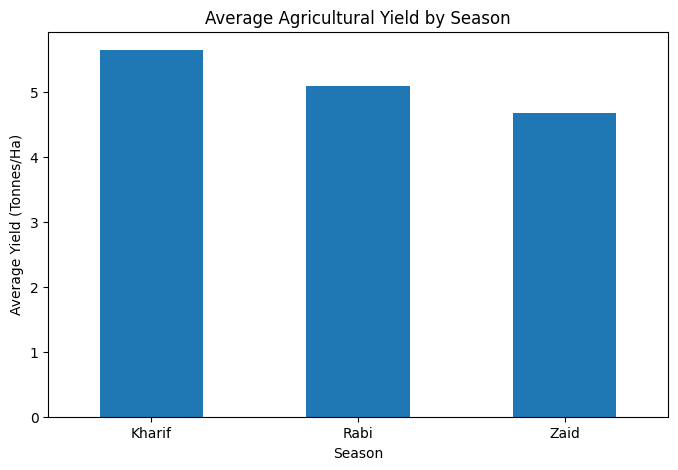

In [ ]:
season_performance['Yield_Tonnes_Ha'].plot(
    kind='bar',
    figsize=(8,5),
    title='Average Agricultural Yield by Season'
)

plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.show()

Creates a bar chart showing the average agricultural yield for each season, with seasons on the X-axis and average yield in Tonnes/Ha on the Y-axis. This helps compare yield performance across different seasons.

**2. What major seasonal patterns can be observed?**\
Here we don't look at only one variable. We look at several variables together.

In [ ]:
season_pattern = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean'
}).round(2)

print(season_pattern)

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                     
Kharif       852.08              28.45         71.81                6.79   
Rabi         436.00              23.49         57.89                7.59   
Zaid         299.42              31.04         52.01                8.18   

        Soil_Moisture_pct  Yield_Tonnes_Ha  Profit_INR  Water_Used_m3  
Season                                                                 
Kharif              31.20             5.64   178914.65        6102.20  
Rabi                24.05             5.08    87689.47        5846.99  
Zaid                19.17             4.67   -24804.82        6419.89  


Calculates the average weather, soil, crop, profit, and water-use conditions for each season. The results are rounded to 2 decimal places to identify seasonal patterns and compare agricultural performance.

*Visualization for the above content is:*

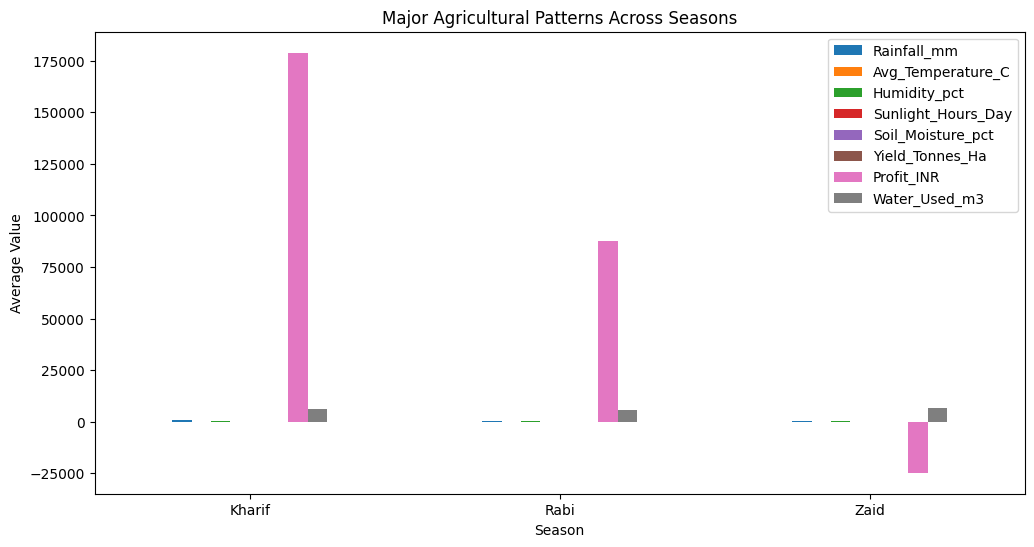

In [ ]:
season_pattern.plot(
    kind='bar',
    figsize=(12,6),
    title='Major Agricultural Patterns Across Seasons'
)

plt.xlabel('Season')
plt.xticks(rotation=0)
plt.ylabel('Average Value')
plt.show()

Creates a bar chart comparing major agricultural patterns across seasons, including weather conditions, soil moisture, yield, profit, and water usage. This helps visualize how different agricultural factors vary between seasons.

**3.Which characteristics change between seasons?**

In [9]:
characteristics = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score'
]

characteristic_comparison = df.groupby('Season')[characteristics].mean().round(2)

print(characteristic_comparison.T)

Season              Kharif    Rabi    Zaid
Rainfall_mm         852.08  436.00  299.42
Avg_Temperature_C    28.45   23.49   31.04
Humidity_pct         71.81   57.89   52.01
Sunlight_Hours_Day    6.79    7.59    8.18
Soil_pH               6.73    6.67    6.69
Soil_Moisture_pct    31.20   24.05   19.17
Nitrogen_kg_ha      120.02  120.40  120.53
Phosphorus_kg_ha     58.10   57.31   58.13
Potassium_kg_ha     105.30  103.93  105.42
Fertilizer_kg_ha    187.08  185.41  184.64
Pesticide_Litre_ha    5.08    5.02    5.17
Seed_Quality_Score    0.82    0.83    0.82


Calculates the average environmental, soil, nutrient, fertilizer, pesticide, and seed-quality characteristics for each season. The results are rounded to 2 decimal places and transposed for easy comparison across seasons.

**4. What differences exist between agricultural activities in different seasons?**
Crop Distribution

In [ ]:
crop_season = pd.crosstab(df['Crop'], df['Season'])

print(crop_season)

Season     Kharif  Rabi  Zaid
Crop                         
Chilli        185   163    64
Cotton        215   201    92
Groundnut     193   177    54
Maize         234   233    84
Pulses        221   213    62
Rice          314   274   102
Sugarcane     125   129    51
Wheat         292   237    85


Creates a cross-tabulation of crops and seasons, showing how many records of each crop are present in each season. This helps analyze the distribution of different crops across seasons.

*Visualization for above content is :*

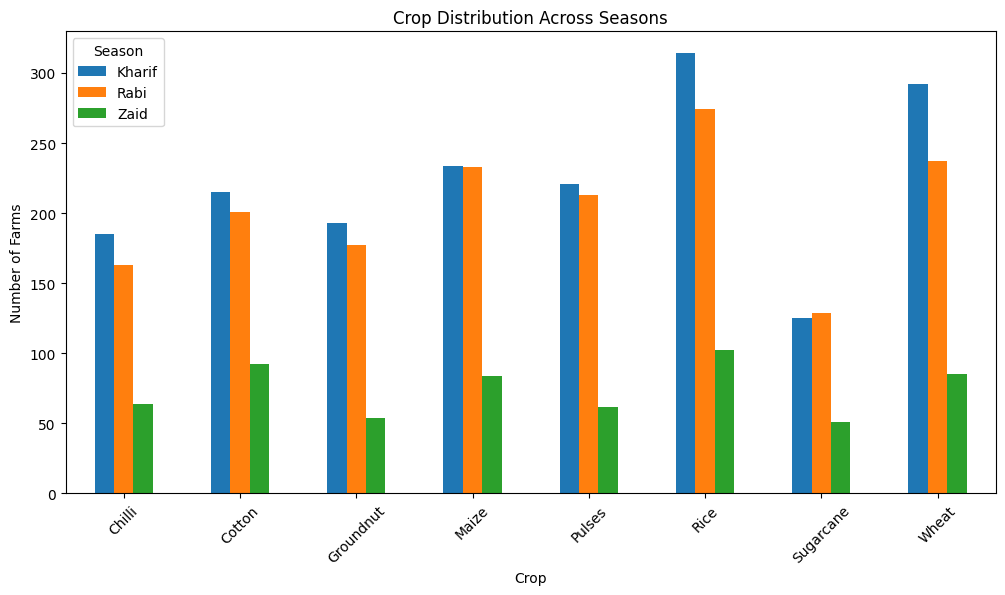

In [ ]:
crop_season.plot(
    kind='bar',
    figsize=(12,6),
    title='Crop Distribution Across Seasons'
)

plt.xlabel('Crop')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)
plt.show()

Creates a **bar chart showing the number of farms growing each crop across different seasons**. It helps compare **crop distribution and seasonal farming patterns** in the dataset.


*Irrigation methods*

In [ ]:
irrigation_season = pd.crosstab(
    df['Irrigation_Method'],
    df['Season']
)

print(irrigation_season)

Season             Kharif  Rabi  Zaid
Irrigation_Method                    
Drip                  405   370   140
Flood                 590   526   194
Rainfed               463   438   140
Sprinkler             321   293   120


Creates a cross-tabulation showing irrigation methods used across different seasons

**5. Are there noticeable variations in resource usage across seasons?**

In [ ]:
resource_usage = df.groupby('Season').agg({
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

print(resource_usage)

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3  \
Season                                                        
Kharif            187.08                5.08        6102.20   
Rabi              185.41                5.02        5846.99   
Zaid              184.64                5.17        6419.89   

        Water_Efficiency_t_per_1000m3  
Season                                 
Kharif                           5.89  
Rabi                             5.19  
Zaid                             4.41  


Calculates the seasonal average usage of fertilizer, pesticides, water, and water efficiency to compare resource consumption across seasons.

*Visualization for above content is :*

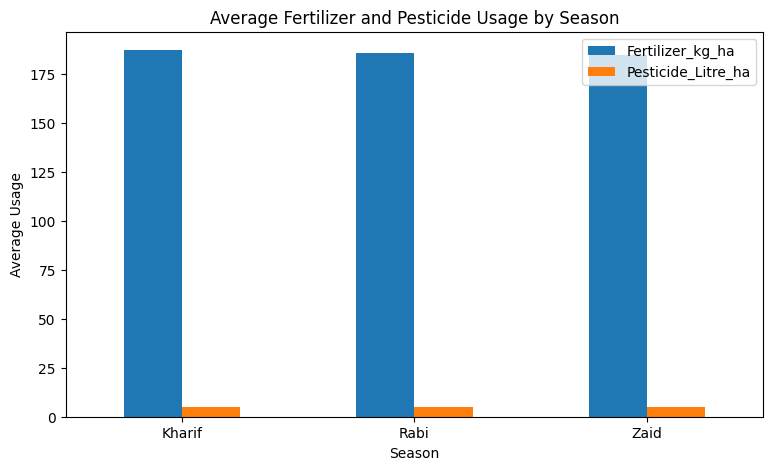

In [ ]:
resource_usage[
    ['Fertilizer_kg_ha', 'Pesticide_Litre_ha']
].plot(
    kind='bar',
    figsize=(9,5),
    title='Average Fertilizer and Pesticide Usage by Season'
)

plt.xlabel('Season')
plt.ylabel('Average Usage')
plt.xticks(rotation=0)
plt.show()

Creates a bar chart comparing the average fertilizer and pesticide usage across different seasons, making seasonal resource consumption easy to visualize.

**6. Are there relationships between environmental conditions and agricultural performance?**

In [ ]:
environmental_variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Disease_Pest_Risk_pct'
]

correlation = df[
    environmental_variables + ['Yield_Tonnes_Ha']
].corr()

print(correlation['Yield_Tonnes_Ha'].sort_values(ascending=False))

Yield_Tonnes_Ha          1.000000
Rainfall_mm              0.030853
Disease_Pest_Risk_pct    0.013490
Humidity_pct             0.011277
Soil_Moisture_pct        0.010210
Avg_Temperature_C        0.009349
Sunlight_Hours_Day      -0.015362
Name: Yield_Tonnes_Ha, dtype: float64


Analyzes the correlation between environmental factors and crop yield, then ranks the variables based on their relationship with yield.

*Visualization for above content is :*

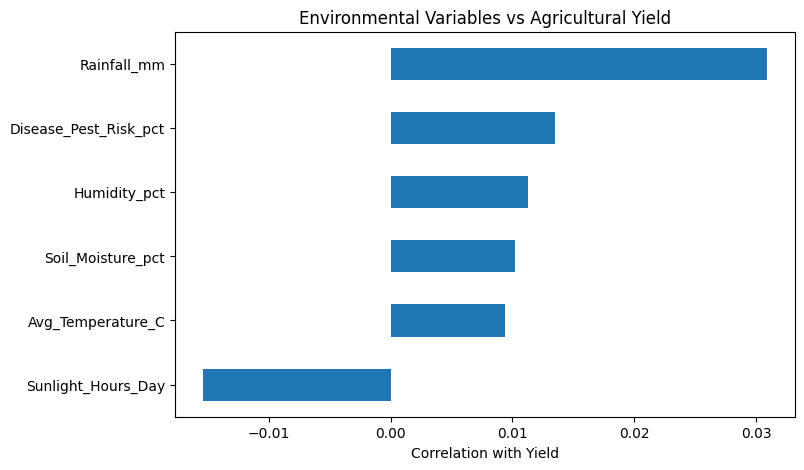

In [ ]:
plt.figure(figsize=(8,5))

correlation['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values().plot(
    kind='barh'
)

plt.title('Environmental Variables vs Agricultural Yield')
plt.xlabel('Correlation with Yield')
plt.show()

Creates a horizontal bar chart showing the correlation between environmental variables and agricultural yield, making positive and negative relationships with yield easy to compare.

**7. How do economic outcomes vary across seasons?**

In [ ]:
economic = df.groupby('Season').agg({
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

print(economic)

        Total_Cost_INR  Revenue_INR  Profit_INR
Season                                         
Kharif       531804.41    710719.06   178914.65
Rabi         513836.58    601526.05    87689.47
Zaid         543976.73    519171.90   -24804.82


Calculates the average cost, revenue, and profit for each season, helping compare the economic performance of agriculture across different seasons.

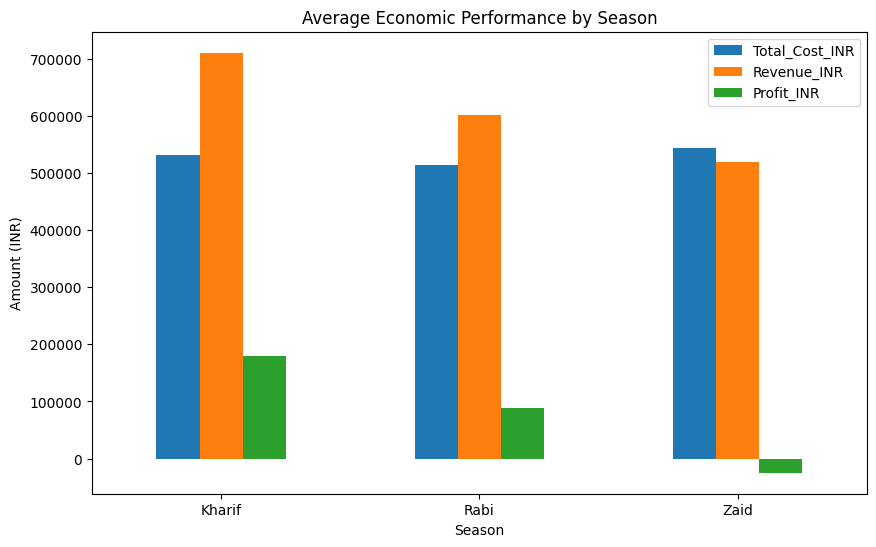

In [15]:
economic = df.groupby('Season').agg({
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

economic.plot(
    kind='bar',
    figsize=(10,6),
    title='Average Economic Performance by Season'
)

plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.show()

Creates a bar chart comparing average cost, revenue, and profit across seasons, helping visualize the overall economic performance of each season.

In [ ]:
profitability = df.groupby('Season').apply(
    lambda x: (x['Profit_INR'] > 0).mean() * 100
)

print("Percentage of profitable farms:")
print(profitability.round(2))

Percentage of profitable farms:
Season
Kharif    57.79
Rabi      48.86
Zaid      35.52
dtype: float64


/tmp/ipykernel_473/163162748.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profitability = df.groupby('Season').apply(


Calculates the percentage of profitable farms in each season by identifying farms with positive profit, helping compare seasonal profitability.

*Visualization for above content is :*

**8. Are some seasonal patterns consistent across different regions or categories?**

In [ ]:
state_season = df.groupby(
    ['State', 'Season']
)['Yield_Tonnes_Ha'].mean().unstack()

print(state_season.round(2))

Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.69  3.49  4.48
Gujarat           6.34  5.52  4.10
Karnataka         6.52  4.61  6.62
Madhya Pradesh    6.00  3.80  5.54
Maharashtra       5.45  5.50  2.29
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.56  4.10
Telangana         5.57  4.83  4.28


Calculates the average crop yield for each state across different seasons, allowing comparison of agricultural productivity by state and season.

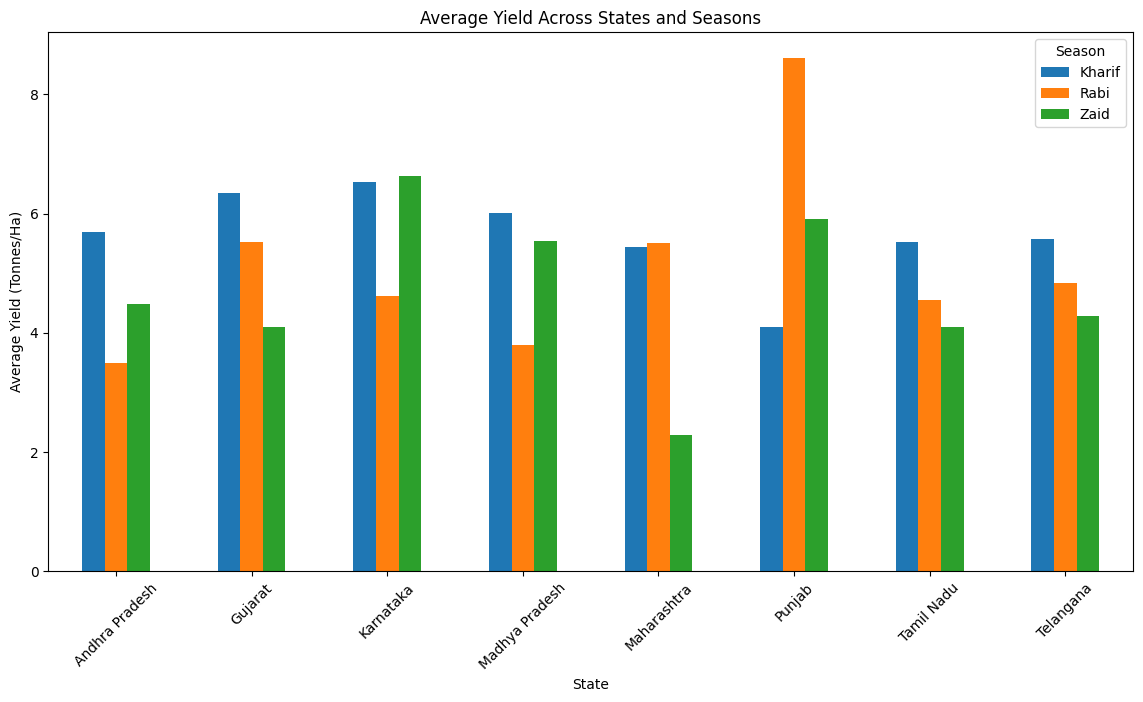

In [ ]:
state_season.plot(
    kind='bar',
    figsize=(14,7),
    title='Average Yield Across States and Seasons'
)

plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

Creates a bar chart comparing average crop yield across different states and seasons, helping identify variations in agricultural productivity.

In [ ]:
crop_season_yield = df.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].mean().unstack()

print(crop_season_yield.round(2))

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.18
Cotton       1.37   1.19   0.95
Groundnut    1.48   1.22   1.04
Maize        2.97   2.61   2.30
Pulses       1.04   0.87   0.65
Rice         2.71   2.33   1.90
Sugarcane   53.46  43.94  38.42
Wheat        2.26   2.06   1.75


Calculates the average yield of each crop across different seasons, helping compare crop productivity and seasonal performance.

**9. Are there unusual or unexpected seasonal patterns?**

In [ ]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['Yield_Tonnes_Ha'] < lower_limit) |
    (df['Yield_Tonnes_Ha'] > upper_limit)
]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Yield Outliers:", len(outliers))

print("\nOutliers by Season:")
print(outliers['Season'].value_counts())

Lower Limit: -1.6349999999999996
Upper Limit: 5.5249999999999995
Number of Yield Outliers: 302

Outliers by Season:
Season
Kharif    129
Rabi      124
Zaid       49
Name: count, dtype: int64


Identifies yield outliers using the IQR method, calculates the lower and upper limits, counts the unusual yield values, and shows their distribution across seasons.


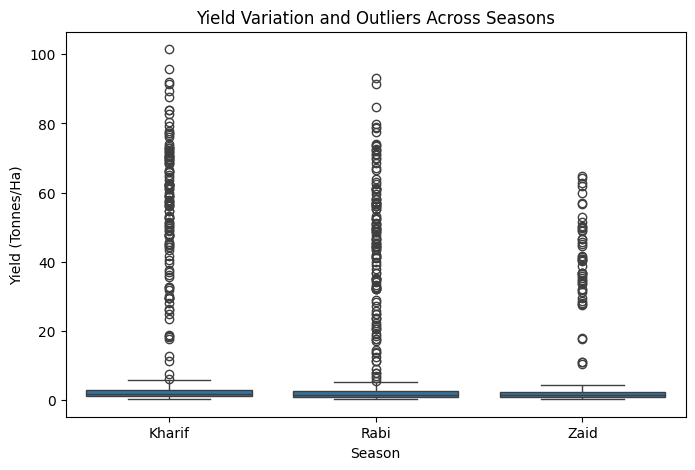

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df)

plt.title("Yield Variation and Outliers Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

Creates a box plot showing yield variation and outliers across different seasons, making it easy to compare yield distribution and identify unusual values.

*Visualization for above content is :*

In [ ]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['Yield_Tonnes_Ha'] < lower_limit) |
    (df['Yield_Tonnes_Ha'] > upper_limit)
]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Yield Outliers:", len(outliers))

print("\nOutliers by Season:")
print(outliers['Season'].value_counts())

Lower Limit: -1.6349999999999996
Upper Limit: 5.5249999999999995
Number of Yield Outliers: 302

Outliers by Season:
Season
Kharif    129
Rabi      124
Zaid       49
Name: count, dtype: int64


Identifies unusual crop yield values using the IQR method, determines the acceptable yield range, counts the outliers, and shows their distribution across seasons.

**10. What insights can be derived from the observed seasonal differences?**

In [20]:
insights = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

print(insights)

        Yield_Tonnes_Ha  Revenue_INR  Profit_INR  Water_Used_m3  \
Season                                                            
Kharif             5.64    710719.06   178914.65        6102.20   
Rabi               5.08    601526.05    87689.47        5846.99   
Zaid               4.67    519171.90   -24804.82        6419.89   

        Water_Efficiency_t_per_1000m3  Disease_Pest_Risk_pct  
Season                                                        
Kharif                           5.89                  54.47  
Rabi                             5.19                  40.48  
Zaid                             4.41                  38.22  


Summarizes key agricultural performance indicators for each season, including yield, revenue, profit, water usage, water efficiency, and disease/pest risk.

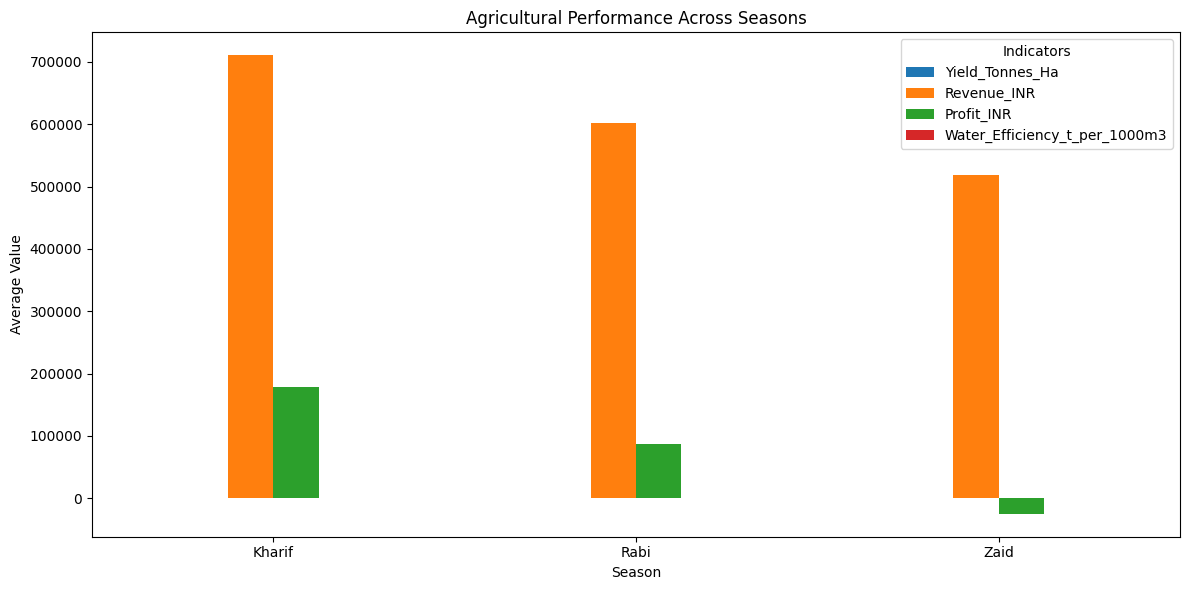

In [24]:
plot_data = insights[
    ['Yield_Tonnes_Ha',
     'Revenue_INR',
     'Profit_INR',
     'Water_Efficiency_t_per_1000m3']
]

plot_data.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Agricultural Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Indicators")
plt.tight_layout()
plt.show()

Creates a bar chart comparing yield, revenue, profit, and water efficiency across seasons, providing an overall view of agricultural performance.

**11. What conclusions can reasonably be drawn from the available data?**

In [ ]:
from scipy.stats import f_oneway

kharif = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha'].dropna()
rabi = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha'].dropna()
zaid = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha'].dropna()

statistic, p_value = f_oneway(kharif, rabi, zaid)

print("ANOVA F-statistic:", statistic)
print("ANOVA p-value:", p_value)

if p_value < 0.05:
    print("The seasonal yield differences are statistically significant.")
else:
    print("The seasonal yield differences are not statistically significant.")

ANOVA F-statistic: 1.4579589466621523
ANOVA p-value: 0.23283549440109827
The seasonal yield differences are not statistically significant.


Performs a one-way ANOVA test to determine whether the average crop yields of Kharif, Rabi, and Zaid seasons differ significantly, using the p-value to draw the conclusion.

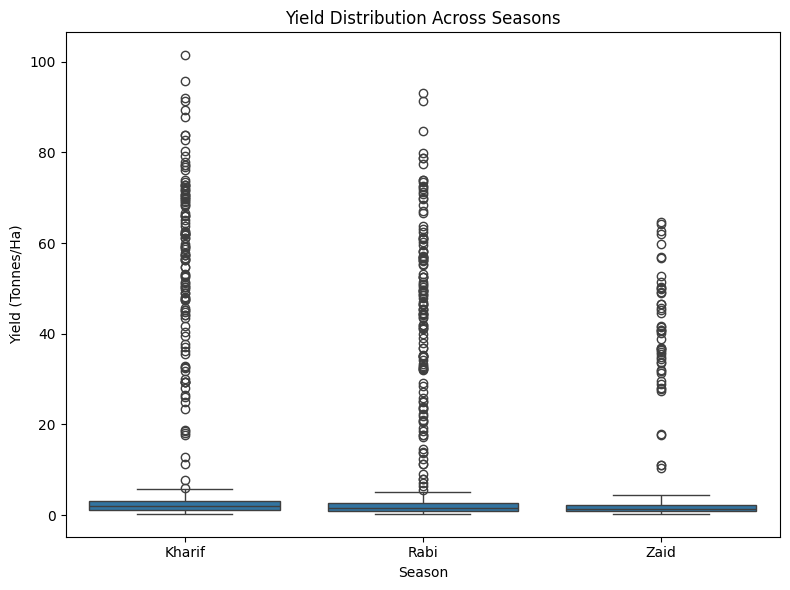

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Season',
    y='Yield_Tonnes_Ha',
    data=df
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

**Yield Distribution Across Seasons:** Creates a **box plot** to compare crop yield distributions across Kharif, Rabi, and Zaid seasons, showing the median, variation, and potential outliers in yield.


**12. How could the findings support better seasonal agricultural planning?**

In [ ]:
planning = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

print(planning)

        Yield_Tonnes_Ha  Profit_INR  Water_Used_m3  \
Season                                               
Kharif             5.64   178914.65        6102.20   
Rabi               5.08    87689.47        5846.99   
Zaid               4.67   -24804.82        6419.89   

        Water_Efficiency_t_per_1000m3  Disease_Pest_Risk_pct  
Season                                                        
Kharif                           5.89                  54.47  
Rabi                             5.19                  40.48  
Zaid                             4.41                  38.22  


**Seasonal Planning Analysis:** Calculates the average yield, profit, water usage, water efficiency, and disease/pest risk for each season to support better agricultural planning and decision-making.


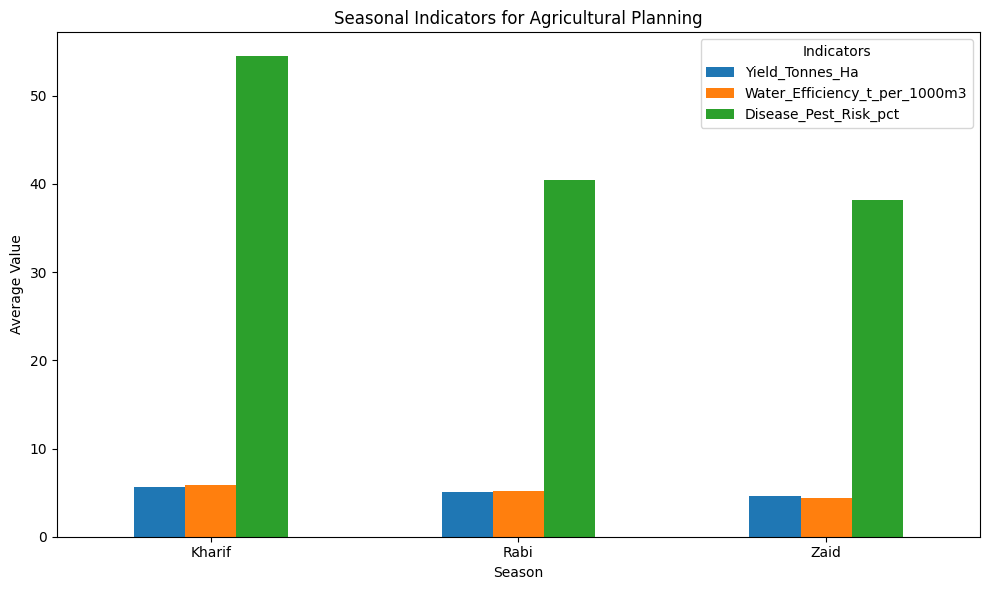

In [25]:
planning_data = insights[
    ['Yield_Tonnes_Ha',
     'Water_Efficiency_t_per_1000m3',
     'Disease_Pest_Risk_pct']
]

planning_data.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Seasonal Indicators for Agricultural Planning")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Indicators")
plt.tight_layout()
plt.show()

**Seasonal Agricultural Planning Indicators:** Creates a **bar chart** comparing average yield, water efficiency, and disease/pest risk across seasons, helping identify suitable seasons for efficient and productive agricultural planning.
